In [7]:
import os
import json
import numpy as np
import pandas as pd
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, Callback
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')
PROJECT_ROOT = Path('/content/drive/MyDrive/TA_SER')

FEATURES_ROOT    = PROJECT_ROOT / 'data' / 'processed' / 'features_v4'
LABEL_ENCODER_FP = PROJECT_ROOT / 'data' / 'processed' / 'label_encoder.json'
MODEL_DIR        = PROJECT_ROOT / 'saved_models' / 'v4'
REPORTS_DIR      = PROJECT_ROOT / 'reports'

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE       = 32
MAX_EPOCHS       = 100
LEARNING_RATE    = 0.001
LABEL_SMOOTHING  = 0.1
L2_REG           = 0.0002
DROPOUT_CONV     = 0.25
DROPOUT_INTEGRATE= 0.35
DROPOUT_DENSE    = 0.5
PATIENCE_ES      = 15
PATIENCE_LR      = 7
LR_FACTOR        = 0.5
MIN_LR           = 1e-6

MODEL_NAME       = 'model_C_v2'
BRANCH_FILTERS   = 64
BRANCH_KERNELS   = [3, 5, 7]
BRANCH_DILATIONS = [1, 2, 3]
PADDING_MODE     = 'same'
INTEGRATE_FILTERS= 128
INTEGRATE_KERNEL = 3
DENSE_UNITS      = 128

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

INPUT_SHAPE = (188, 40)
NUM_CLASSES = 4

print(f'TF version: {tf.__version__}')
print(f'Model name: {MODEL_NAME}')
print(f'Branch filters : {BRANCH_FILTERS} (TRIAL)')
print(f'Branch dilations: {BRANCH_DILATIONS} (TRIAL)')
print(f'Padding: {PADDING_MODE} (TRIAL)')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TF version: 2.19.0
Model name: model_C_v2
Branch filters : 64 (TRIAL)
Branch dilations: [1, 2, 3] (TRIAL)
Padding: same (TRIAL)


In [ ]:
with open(LABEL_ENCODER_FP, 'r') as f:
    label_enc = json.load(f)

LABEL_TO_INT  = label_enc['label_to_int']
INT_TO_LABEL  = {int(k): v for k, v in label_enc['int_to_label'].items()}
TARGET_LABELS = label_enc['target_labels']

print(f'Target labels: {TARGET_LABELS}')


Target labels: ['angry', 'happy', 'neutral', 'sad']


In [ ]:
X_train = np.load(FEATURES_ROOT / 'train' / 'X_train.npy')
y_train = np.load(FEATURES_ROOT / 'train' / 'y_train.npy')
sources_train = np.load(FEATURES_ROOT / 'train' / 'sources_train.npy', allow_pickle=True)
y_train_oh = to_categorical(y_train, num_classes=NUM_CLASSES)

print(f'X_train: {X_train.shape}')

val_per_source = {}
for src in ['ravdess', 'emodb', 'tess', 'savee']:
    X_v = np.load(FEATURES_ROOT / 'val' / f'X_val_{src}.npy')
    y_v = np.load(FEATURES_ROOT / 'val' / f'y_val_{src}.npy')
    val_per_source[src] = {
        'X': X_v,
        'y': y_v,
        'y_oh': to_categorical(y_v, num_classes=NUM_CLASSES)
    }
    print(f'  val_{src}: {X_v.shape}')

X_val_combined = np.load(FEATURES_ROOT / 'val' / 'X_val_combined.npy')
y_val_combined = np.load(FEATURES_ROOT / 'val' / 'y_val_combined.npy')
y_val_combined_oh = to_categorical(y_val_combined, num_classes=NUM_CLASSES)
print(f'X_val_combined: {X_val_combined.shape}')


X_train: (9312, 188, 40)
  val_ravdess: (67, 188, 40)
  val_emodb: (34, 188, 40)
  val_tess: (160, 188, 40)
  val_savee: (30, 188, 40)
X_val_combined: (291, 188, 40)


In [ ]:
def build_branch(x, filters, kernel_size, dilation_rate, name_prefix):

    x = layers.Conv1D(
        filters, kernel_size=kernel_size,
        dilation_rate=dilation_rate,
        padding=PADDING_MODE,
        kernel_regularizer=keras.regularizers.l2(L2_REG),
        name=f'{name_prefix}_conv'
    )(x)
    x = layers.BatchNormalization(name=f'{name_prefix}_bn')(x)
    x = layers.Activation('relu', name=f'{name_prefix}_relu')(x)
    x = layers.Dropout(DROPOUT_CONV, name=f'{name_prefix}_drop')(x)
    x = layers.MaxPooling1D(pool_size=2, name=f'{name_prefix}_pool')(x)
    return x


def build_model(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape, name='input')

    branches = []
    for i, (k, d) in enumerate(zip(BRANCH_KERNELS, BRANCH_DILATIONS)):
        branch = build_branch(
            inputs,
            filters=BRANCH_FILTERS,
            kernel_size=k,
            dilation_rate=d,
            name_prefix=f'branch{i+1}_k{k}_d{d}'
        )
        branches.append(branch)

    x = layers.Concatenate(axis=-1, name='concat')(branches)

    x = layers.Conv1D(
        INTEGRATE_FILTERS, kernel_size=INTEGRATE_KERNEL, padding='same',
        kernel_regularizer=keras.regularizers.l2(L2_REG),
        name='integrate_conv'
    )(x)
    x = layers.BatchNormalization(name='integrate_bn')(x)
    x = layers.Activation('relu', name='integrate_relu')(x)
    x = layers.Dropout(DROPOUT_INTEGRATE, name='integrate_drop')(x)

    x = layers.GlobalAveragePooling1D(name='gap')(x)
    x = layers.Dense(
        DENSE_UNITS, activation='relu',
        kernel_regularizer=keras.regularizers.l2(L2_REG), name='dense1'
    )(x)
    x = layers.Dropout(DROPOUT_DENSE, name='drop_dense')(x)

    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    return keras.Model(inputs=inputs, outputs=outputs, name=MODEL_NAME)


model = build_model()
model.summary()
total_params = model.count_params()
print(f'\n Total params: {total_params:,}')


Model: "model_C_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 188, 40)   │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch1_k3_d1_conv  │ (None, 188, 64)   │      7,744 │ input[0][0]       │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch2_k5_d2_conv  │ (None, 188, 64)   │     12,864 │ input[0][0]       │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch3_k7_d3_conv  │ (None, 188, 64)   │     17,984 │ input[0][0]       │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch1_k3_d1_bn    │ (None, 188, 64)   │        256 │ branch1_k3_d1_co… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch2_k5_d2_bn    │ (None, 188, 64)   │        256 │ branch2_k5_d2_co… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch3_k7_d3_bn    │ (None, 188, 64)   │        256 │ branch3_k7_d3_co… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch1_k3_d1_relu  │ (None, 188, 64)   │          0 │ branch1_k3_d1_bn… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch2_k5_d2_relu  │ (None, 188, 64)   │          0 │ branch2_k5_d2_bn… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch3_k7_d3_relu  │ (None, 188, 64)   │          0 │ branch3_k7_d3_bn… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch1_k3_d1_drop  │ (None, 188, 64)   │          0 │ branch1_k3_d1_re… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch2_k5_d2_drop  │ (None, 188, 64)   │          0 │ branch2_k5_d2_re… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch3_k7_d3_drop  │ (None, 188, 64)   │          0 │ branch3_k7_d3_re… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch1_k3_d1_pool  │ (None, 94, 64)    │          0 │ branch1_k3_d1_dr… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch2_k5_d2_pool  │ (None, 94, 64)    │          0 │ branch2_k5_d2_dr… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch3_k7_d3_pool  │ (None, 94, 64)    │          0 │ branch3_k7_d3_dr… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 94, 192)   │          0 │ branch1_k3_d1_po… │
│ (Concatenate)       │                   │            │ branch2_k5_d2_po

 Total params: 130,756 (510.77 KB)

 Trainable params: 130,116 (508.27 KB)

 Non-trainable params: 640 (2.50 KB)


 Total params: 130,756


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss=CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=['accuracy']
)
print(' Model compiled')


 Model compiled


In [ ]:
class PerSourceValAccCallback(Callback):
    def __init__(self, val_per_source):
        super().__init__()
        self.val_per_source = val_per_source
        self.history_per_source = {src: [] for src in val_per_source.keys()}

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        for src, data in self.val_per_source.items():
            y_pred = self.model.predict(data['X'], verbose=0)
            y_pred_class = np.argmax(y_pred, axis=1)
            acc = float(np.mean(y_pred_class == data['y']))
            self.history_per_source[src].append(acc)
            logs[f'val_acc_{src}'] = acc


per_source_callback = PerSourceValAccCallback(val_per_source)
print(' Callback initialized')


 Callback initialized


In [ ]:
checkpoint_path = MODEL_DIR / f'{MODEL_NAME}_best.keras'

callbacks = [
    EarlyStopping(monitor='val_loss', patience=PATIENCE_ES, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=PATIENCE_LR, factor=LR_FACTOR, min_lr=MIN_LR, verbose=1),
    ModelCheckpoint(filepath=str(checkpoint_path), monitor='val_loss', save_best_only=True, verbose=0),
    per_source_callback
]

print(f' Callbacks setup | checkpoint: {checkpoint_path.name}')


 Callbacks setup | checkpoint: model_C_v2_best.keras


In [ ]:
history = model.fit(
    X_train, y_train_oh,
    validation_data=(X_val_combined, y_val_combined_oh),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
    shuffle=True
)

print(f'\n Training complete')
print(f' Final epoch: {len(history.history["loss"])}')
print(f' Best val_loss: {min(history.history["val_loss"]):.4f}')
print(f' Best val_acc : {max(history.history["val_accuracy"]):.4f}')


Epoch 1/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.7561 - loss: 0.9023 - val_accuracy: 0.8316 - val_loss: 0.7994 - learning_rate: 0.0010 - val_acc_ravdess: 0.5821 - val_acc_emodb: 0.6471 - val_acc_tess: 0.9875 - val_acc_savee: 0.7667
Epoch 2/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8447 - loss: 0.7445 - val_accuracy: 0.8488 - val_loss: 0.7069 - learning_rate: 0.0010 - val_acc_ravdess: 0.5970 - val_acc_emodb: 0.7647 - val_acc_tess: 1.0000 - val_acc_savee: 0.7000
Epoch 3/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8745 - loss: 0.6912 - val_accuracy: 0.8832 - val_loss: 0.6728 - learning_rate: 0.0010 - val_acc_ravdess: 0.6866 - val_acc_emodb: 0.8529 - val_acc_tess: 1.0000 - val_acc_savee: 0.7333
Epoch 4/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8986 - loss: 0.6525 - val_accuracy: 0.8832 - val_loss: 0.6774 - learning_rate: 0.0010 - val_acc_ravdess: 0.6716 - val_acc_emodb: 0.7941 - val_acc_tess: 1.0000 - val_acc_savee: 0.83

In [ ]:
full_history = dict(history.history)
full_history['val_acc_per_source'] = per_source_callback.history_per_source

def sanitize(obj):
    if isinstance(obj, dict):
        return {k: sanitize(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [sanitize(v) for v in obj]
    if isinstance(obj, (np.floating, np.integer)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

full_history_clean = sanitize(full_history)
full_history_clean['_metadata'] = {
    'model_name': MODEL_NAME,
    'is_trial': True,
    'input_shape': list(INPUT_SHAPE),
    'num_classes': NUM_CLASSES,
    'total_params': int(total_params),
    'config': {
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'label_smoothing': LABEL_SMOOTHING,
        'l2_reg': L2_REG,
        'dropout_conv': DROPOUT_CONV,
        'dropout_integrate': DROPOUT_INTEGRATE,
        'dropout_dense': DROPOUT_DENSE,
        'branch_filters': BRANCH_FILTERS,
        'branch_kernels': BRANCH_KERNELS,
        'branch_dilations': BRANCH_DILATIONS,
        'padding_mode': PADDING_MODE,
        'integrate_filters': INTEGRATE_FILTERS,
    },
    'epochs_trained': len(history.history['loss']),
    'best_val_loss': float(min(history.history['val_loss'])),
    'best_val_acc': float(max(history.history['val_accuracy'])),
}

# Variant name for filename (e.g. 'C_v2' → 'C_v2')
variant_suffix = MODEL_NAME.replace('model_', '')  # 'C_v2' or 'C_v3'
history_path = MODEL_DIR / f'history_{variant_suffix}.json'
with open(history_path, 'w') as f:
    json.dump(full_history_clean, f, indent=2)

print(f' History saved: {history_path}')


 History saved: /content/drive/MyDrive/TA_SER/saved_models/v4/history_C_v2.json


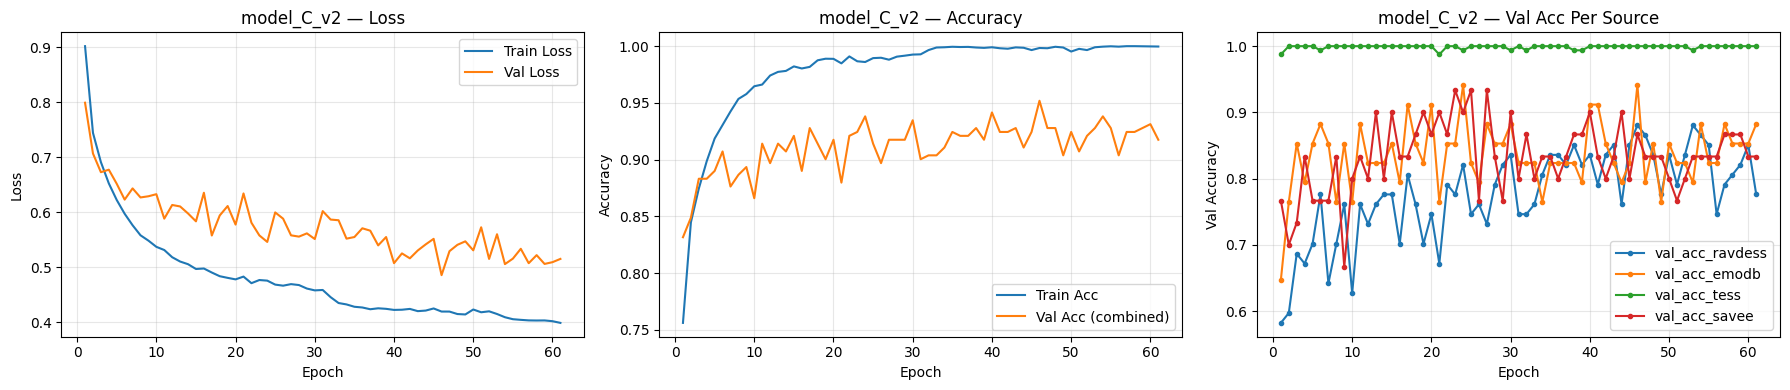

 Plot saved: /content/drive/MyDrive/TA_SER/reports/training_curves_C_v2.png


In [ ]:
epochs = range(1, len(history.history['loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(epochs, history.history['loss'], label='Train Loss')
axes[0].plot(epochs, history.history['val_loss'], label='Val Loss')
axes[0].set_title(f'{MODEL_NAME} — Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history.history['accuracy'], label='Train Acc')
axes[1].plot(epochs, history.history['val_accuracy'], label='Val Acc (combined)')
axes[1].set_title(f'{MODEL_NAME} — Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

for src, acc_list in per_source_callback.history_per_source.items():
    axes[2].plot(range(1, len(acc_list)+1), acc_list, label=f'val_acc_{src}', marker='.')
axes[2].set_title(f'{MODEL_NAME} — Val Acc Per Source')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Val Accuracy')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
curves_path = REPORTS_DIR / f'training_curves_{variant_suffix}.png'
plt.savefig(curves_path, dpi=100, bbox_inches='tight')
plt.show()

print(f' Plot saved: {curves_path}')


In [ ]:
print('=' * 70)
print(f'{MODEL_NAME} — Training Summary')
print('=' * 70)
print(f'Total params          : {total_params:,}')
print(f'Epochs trained        : {len(history.history["loss"])}')
print(f'Best val_loss         : {min(history.history["val_loss"]):.4f}')
print(f'Best val_acc (combined): {max(history.history["val_accuracy"]):.4f}')
print()
print('Final val_acc per source:')
for src, acc_list in per_source_callback.history_per_source.items():
    print(f'  {src:8s}: last={acc_list[-1]:.3f}  best={max(acc_list):.3f}')

print()
print('=' * 70)
print('FULL ABLATION COMPARISON')
print('=' * 70)
try:
    comparison = {}
    for m_name in ['A', 'B', 'C', 'C_v2', 'C_v3']:
        h_path = MODEL_DIR / f'history_{m_name}.json'
        if h_path.exists():
            with open(h_path, 'r') as f:
                h = json.load(f)
            # Get final per-source val acc
            per_src = h.get('val_acc_per_source', {})
            best_per_src = {s: max(accs) if accs else 0 for s, accs in per_src.items()}
            comparison[m_name] = {
                'params': h['_metadata']['total_params'],
                'best_val_loss': h['_metadata']['best_val_loss'],
                'best_val_acc': h['_metadata']['best_val_acc'],
                'per_src': best_per_src
            }

    if comparison:
        # Header
        print(f"{'Model':8s} {'Params':>10s} {'ValLoss':>9s} {'ValAcc':>8s} {'RAVD':>7s} {'EMODB':>7s} {'TESS':>7s} {'SAVEE':>7s}")
        print('-' * 70)
        for m, d in comparison.items():
            per_src = d['per_src']
            print(f"{'Model ' + m:8s} {d['params']:>10,} {d['best_val_loss']:>9.4f} {d['best_val_acc']:>8.4f}"
                  f"{per_src.get('ravdess', 0):>7.3f} {per_src.get('emodb', 0):>7.3f}"
                  f"{per_src.get('tess', 0):>7.3f} {per_src.get('savee', 0):>7.3f}")

        print()
        best_combined = max(comparison.items(), key=lambda x: x[1]['best_val_acc'])
        print(f' Best val_acc (combined): Model {best_combined[0]} ({best_combined[1]["best_val_acc"]:.4f})')

        # Check if trial beat baseline
        if 'A' in comparison:
            baseline_acc = comparison['A']['best_val_acc']
            trial_acc = max(history.history['val_accuracy'])
            delta = (trial_acc - baseline_acc) * 100
            status = ' BEAT' if delta > 0 else ' LOSE' if delta < -0.5 else '≈ TIE'
            print(f'{MODEL_NAME} vs Model A: {status} (Δ = {delta:+.2f}%)')
    else:
        print('Ga ada history untuk compare')
except Exception as e:
    print(f'Comparison skipped: {e}')

print()
print(f'Checkpoint: {checkpoint_path}')
print(f'History   : {history_path}')
print(f'Plot      : {curves_path}')


model_C_v2 — Training Summary
Total params          : 130,756
Epochs trained        : 61
Best val_loss         : 0.4854
Best val_acc (combined): 0.9519

Final val_acc per source:
  ravdess : last=0.776  best=0.881
  emodb   : last=0.882  best=0.941
  tess    : last=1.000  best=1.000
  savee   : last=0.833  best=0.933

FULL ABLATION COMPARISON
Model        Params   ValLoss   ValAcc    RAVD   EMODB    TESS   SAVEE
----------------------------------------------------------------------
Model A     253,252    0.4837   0.9450  0.881   0.941  1.000   0.967
Model B     130,756    0.5214   0.9347  0.851   0.912  1.000   0.933
Model C     130,756    0.5167   0.9313  0.851   0.853  1.000   0.933
Model C_v2    130,756    0.4854   0.9519  0.881   0.941  1.000   0.933

 Best val_acc (combined): Model C_v2 (0.9519)
model_C_v2 vs Model A:  BEAT (Δ = +0.69%)

Checkpoint: /content/drive/MyDrive/TA_SER/saved_models/v4/model_C_v2_best.keras
History   : /content/drive/MyDrive/TA_SER/saved_models/v4/history

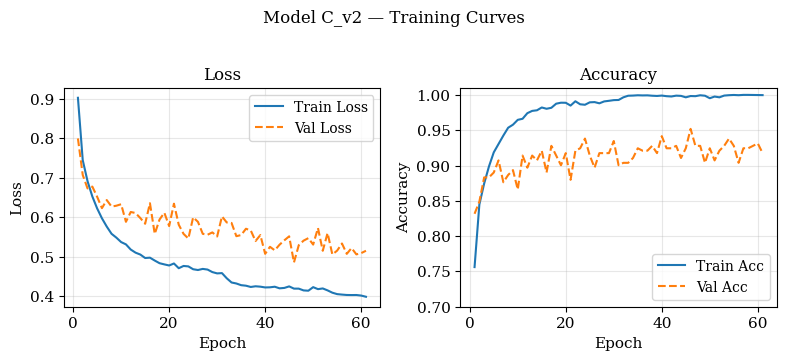

Saved: /content/drive/MyDrive/TA_SER/reports/paper_training_curve_C_v2.png


In [8]:
# ============================================================
# FIGURE: Training Curve - Model C_v2 (Paper Version, 2 panel)
# Paste sebagai cell BARU di NB03c_v2, jangan hapus cell lama
# Pastikan variabel 'history' masih ada di memory,
# kalau tidak, load dulu dari JSON:
# ============================================================

# Kalau history belum ada di memory, load dari file:
import json
history_path = PROJECT_ROOT / 'saved_models' / 'v4' / 'history_C_v2.json'
# Kalau nama filenya beda, sesuaikan

with open(history_path, 'r') as f:
    hist = json.load(f)

# ---- Plot ----
import matplotlib
matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
})

epochs = range(1, len(hist['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))

# Panel kiri: Loss
axes[0].plot(epochs, hist['loss'],     color='#1f77b4', lw=1.5, label='Train Loss')
axes[0].plot(epochs, hist['val_loss'], color='#ff7f0e', lw=1.5, label='Val Loss',
             linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel kanan: Accuracy
# Key name mungkin 'accuracy' atau 'acc' — cek dulu:
acc_key = 'accuracy' if 'accuracy' in hist else 'acc'
val_acc_key = 'val_accuracy' if 'val_accuracy' in hist else 'val_acc'

axes[1].plot(epochs, hist[acc_key],     color='#1f77b4', lw=1.5, label='Train Acc')
axes[1].plot(epochs, hist[val_acc_key], color='#ff7f0e', lw=1.5, label='Val Acc',
             linestyle='--')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy')
axes[1].set_ylim([0.7, 1.01])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Model C_v2 — Training Curves', fontsize=12, y=1.02)
plt.tight_layout()

out_path = REPORTS_DIR / 'paper_training_curve_C_v2.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {out_path}')